IT-Enabled Business Processes

MIT-5672-997


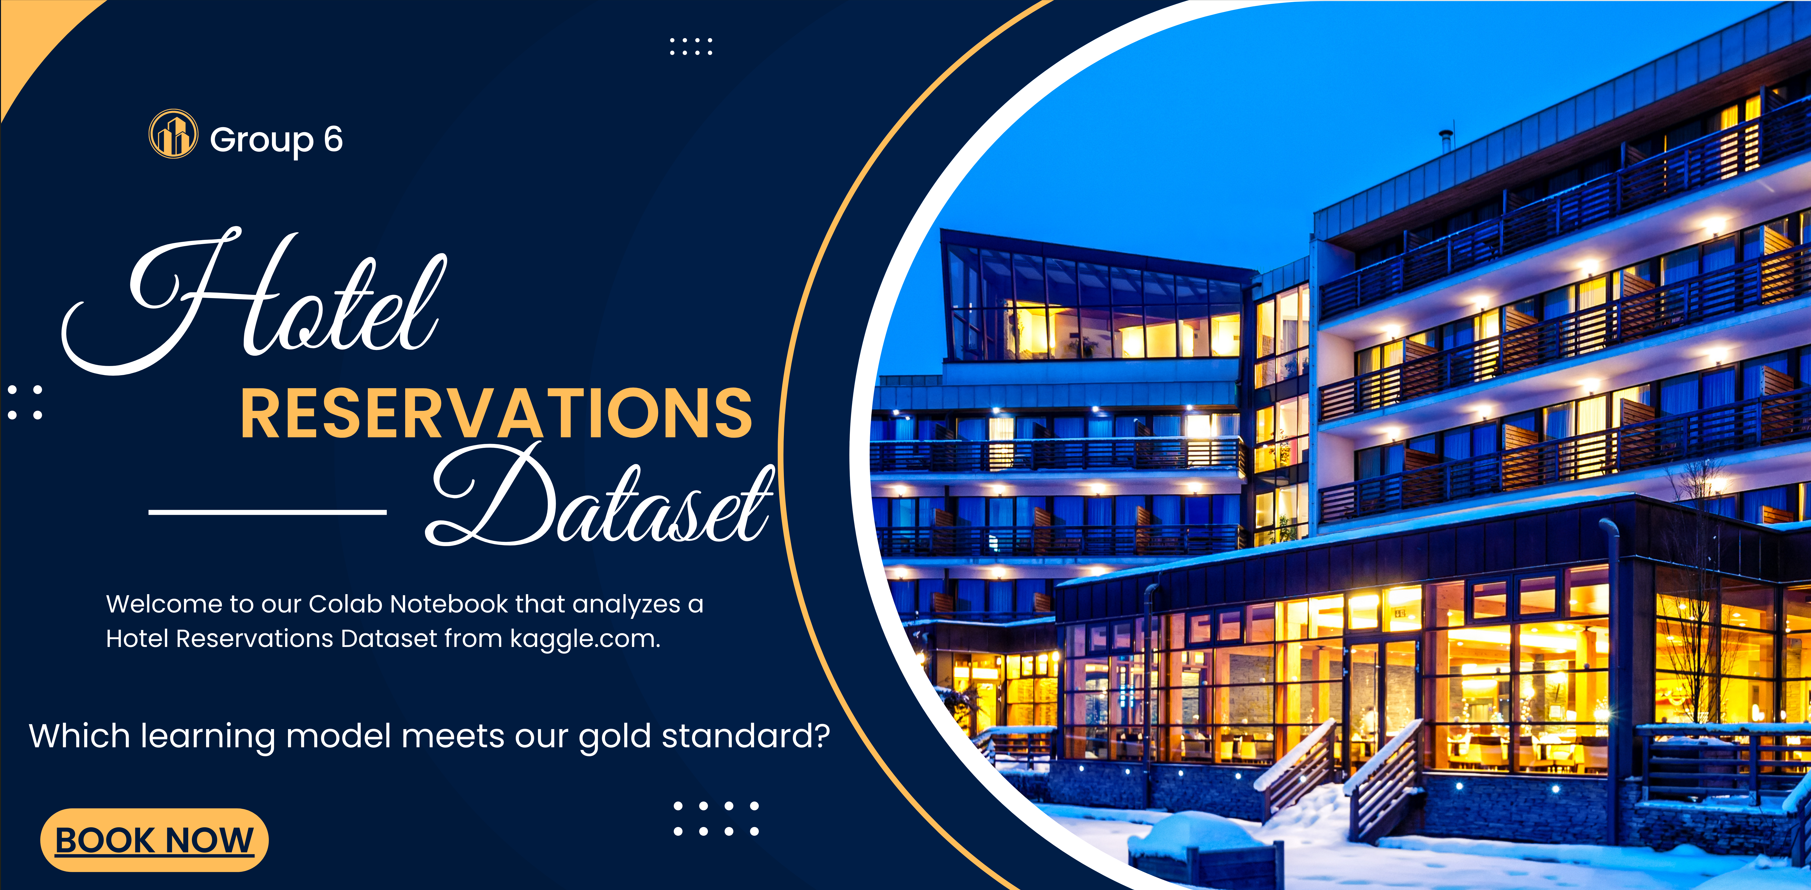

####**Team:**

* Miracle Boykin - Completed Traditional Method section.
* Tricia Hindley - Organized team meetings, organized formatting of colab document, and completed Introduction and Ensemble method sections.
* Storm Leusby - Completed Data Exploration and Preprocessing sections.
* Jase Wickliffe - Submitted documents for group, imported dataset for preprocessing, and completed Deep learning section.

* Team completed Results/Evaluation and Conclusion/Future Work as a team. <br>

##<font color='navy'> Introduction </font>



####Hotel Reservations can be booked by customers online, but are often cancelled for a variety of different reasons. Cancellation reasons include plans changing, scheduling issues, weather changes, etc. Some hotels offer cancellation free of charge or for a small cancellation fee.

#### Real world application -- With the use of machine learning, hotels and hotel booking sites can use anaylze and predict demands, trends, and prices -- including cancellations. This allows hotels to optimize hotel revenue and reduce cancellations.

####Group six will analyze the "Hotel Reservations.csv" dataset from Kaggle. This data set has 36,275 values, with 19 columns. A variety of predictive models will be created to determine how likely a customer will honor their hotel reservation. Each model will be evaulated, and the group will determine which model is the best predictor.
#### This dataset was chosen due to its applicability to ensemble and deep learning.


####**Goal:** Which learning model is the best predictor of determining if a customer will honor their reservation or cancel it?

####**Agenda:**


*   Data Exploration & Preprocessing
*   Modeling: Ensemble, Deep Learning, Traditional Machine.
*   Results & Evaluation
*   Conclusion & Future Work




In [ ]:
#Download dataset
!kaggle datasets download ahsan81/hotel-reservations-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/ahsan81/hotel-reservations-classification-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
hotel-reservations-classification-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Should download to content section in directory. Directory is to the left under the key logo. File was downloaded as zip file. This unzips it

import zipfile
with zipfile.ZipFile('/content/hotel-reservations-classification-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall("/content/")

#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from yellowbrick.classifier import ConfusionMatrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

## <font color='navy'>Import Dataset </font>


#### Here we are reading the database using the name "df" in the variable.

In [ ]:
df = pd.read_csv('/content/Hotel Reservations.csv', sep = ',')
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


#### Here we can see that we have categorical and continuous variables, we can also see that we have this column Booking ID that will probably not be used, we can also see that we don't have null values.

#### Here the explanation about the variables:

- Booking_ID: unique identifier of each booking
- no_of_adults: Number of adults
- no_of_children: Number of Children
- no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
- no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
- type_of_meal_plan: Type of meal plan booked by the customer:
- required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
- room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
- lead_time: Number of days between the date of booking and the arrival date
- arrival_year: Year of arrival date
- arrival_month: Month of arrival date
- arrival_date: Date of the month
- market_segment_type: Market segment designation.
- repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
- no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
- no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
- avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
- no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
- booking_status: Flag indicating if the booking was canceled or not.

In [ ]:
df.head(5)

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [ ]:
(df.isnull().sum()/len(df))

,0
Booking_ID,0.0
no_of_adults,0.0
no_of_children,0.0
no_of_weekend_nights,0.0
no_of_week_nights,0.0
type_of_meal_plan,0.0
required_car_parking_space,0.0
room_type_reserved,0.0
lead_time,0.0
arrival_year,0.0


## <font color='navy'> Data Exploration and Preprocessing - Storm </font>


Data Exploration

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

In [ ]:
# Load the dataset
df = pd.read_csv('/content/Hotel Reservations.csv')

# Preview the first few rows
print("Dataset Shape:", df.shape)
df.head()

# General dataset information
df.info()

# Summary statistics
df.describe()

# Check for missing values
missing_data = df.isnull().sum()
print("Missing Values:\n", missing_data[missing_data > 0])

Dataset Shape: (36275, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  i

Data Analysis

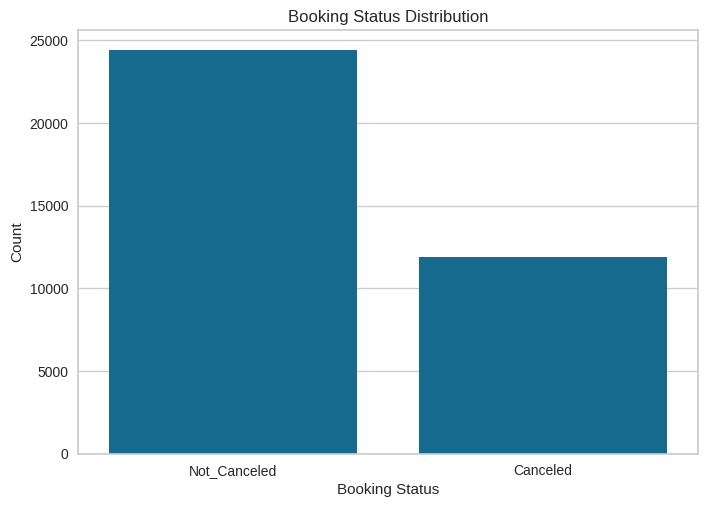

In [ ]:
# Visualize target variable distribution
sns.countplot(data=df, x='booking_status')
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

Correlation Analysis

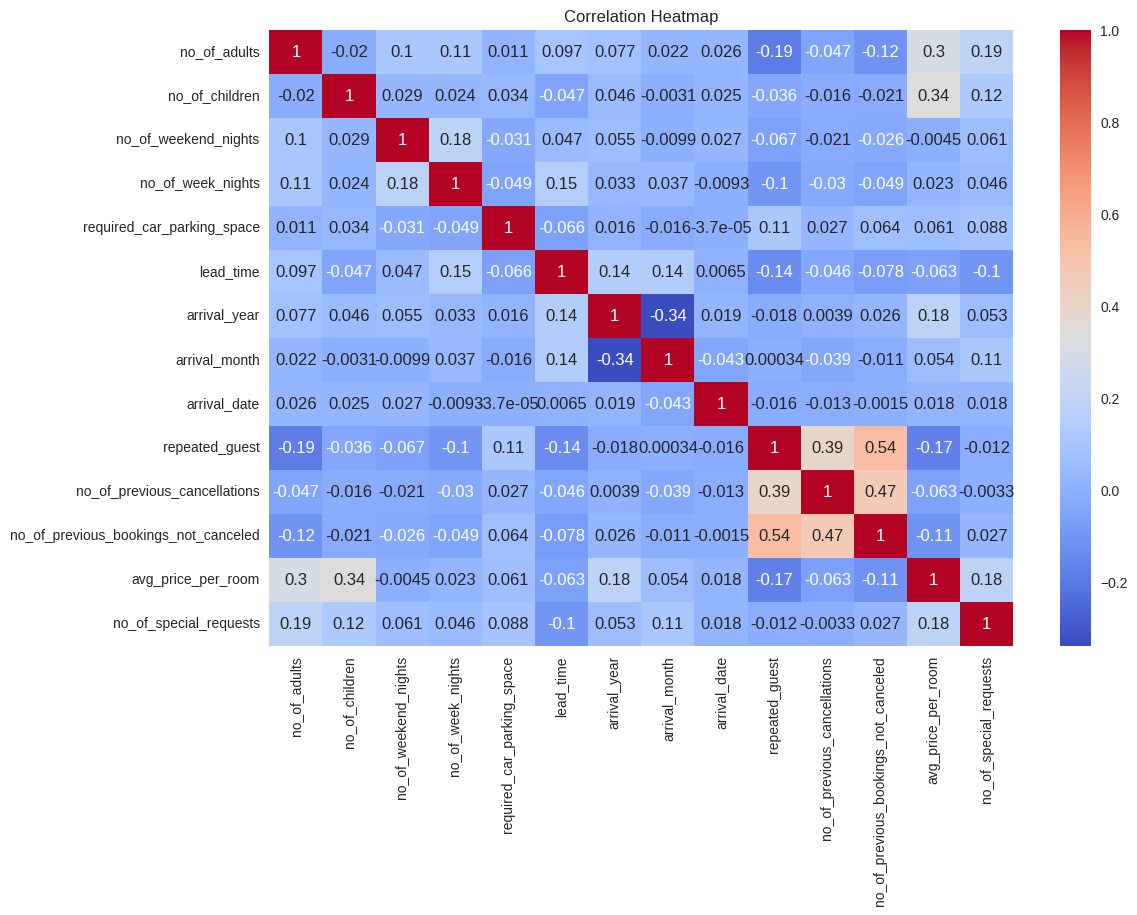

In [ ]:
# Filter only numerical columns for correlation matrix
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute and plot the correlation matrix
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Key Features

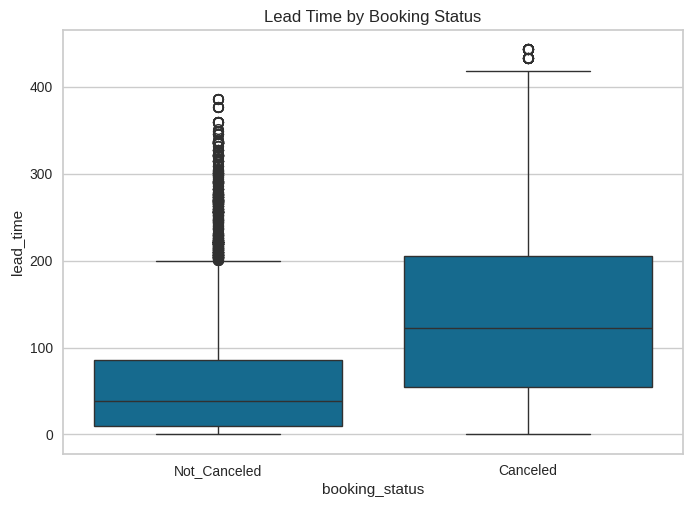

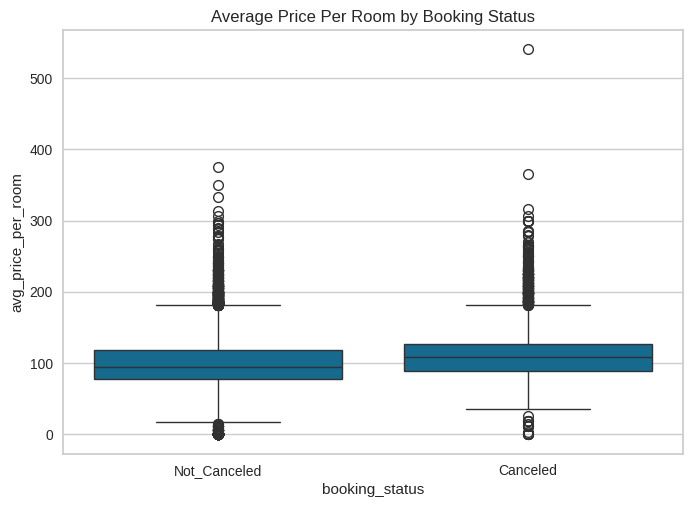

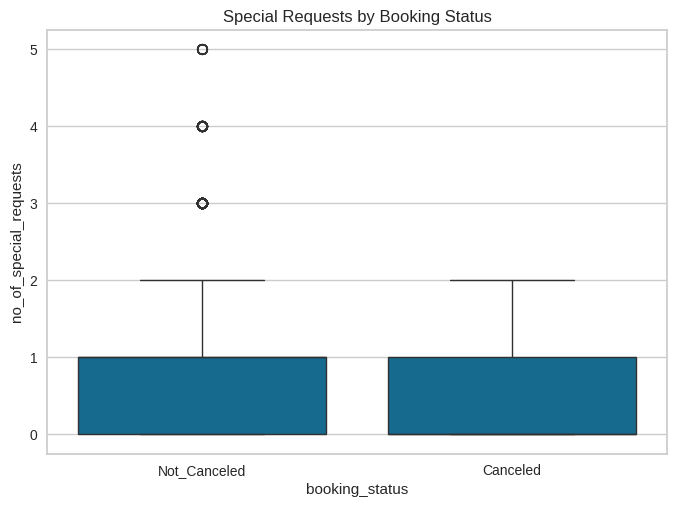

In [ ]:
# Lead Time vs Booking Status
sns.boxplot(data=df, x='booking_status', y='lead_time')
plt.title("Lead Time by Booking Status")
plt.show()

# Average Price Per Room vs Booking Status
sns.boxplot(data=df, x='booking_status', y='avg_price_per_room')
plt.title("Average Price Per Room by Booking Status")
plt.show()

# Number of Special Requests vs Booking Status
sns.boxplot(data=df, x='booking_status', y='no_of_special_requests')
plt.title("Special Requests by Booking Status")
plt.show()

Preprocessing

In [ ]:
# Drop Booking_ID column
df.drop(columns=['Booking_ID'], inplace=True)

Catagorical Variables

In [ ]:
# Encode target variable
label_encoder = LabelEncoder()
df['booking_status'] = label_encoder.fit_transform(df['booking_status'])  # 0 = Cancelled, 1 = Not Cancelled

# One-hot encode categorical features
categorical_features = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

Feature Scaling

In [ ]:
# Scale numerical features
scaler = MinMaxScaler()
numerical_features = ['lead_time', 'avg_price_per_room', 'no_of_special_requests']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Preview scaled features
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,0.505643,2017,10,2,0,...,False,False,False,False,False,False,False,False,True,False
1,2,0,2,3,0,0.011287,2018,11,6,0,...,False,False,False,False,False,False,False,False,False,True
2,1,0,2,1,0,0.002257,2018,2,28,0,...,False,False,False,False,False,False,False,False,False,True
3,2,0,0,2,0,0.476298,2018,5,20,0,...,False,False,False,False,False,False,False,False,False,True
4,2,0,1,1,0,0.108352,2018,4,11,0,...,False,False,False,False,False,False,False,False,False,True


Class Imbalance

Class Distribution:
 booking_status
1    24390
0    11885
Name: count, dtype: int64


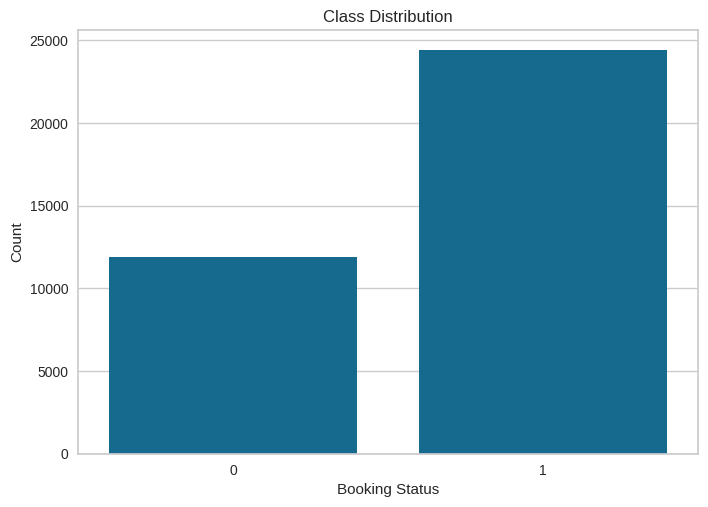

In [ ]:
# Class balance check
class_counts = df['booking_status'].value_counts()
print("Class Distribution:\n", class_counts)

# Visualize class balance
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Class Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Count")
plt.show()

Processed Data



In [ ]:
# Save the processed dataset to a CSV
df.to_csv('/content/processed_hotel_data.csv', index=False)
print("Preprocessed data saved!")

Preprocessed data saved!


## <font color='navy'> Modeling </font>


###  Ensemble Method: Random Forest  --Tricia

*  Random forest was chosen as opposed to Gradient Boosting or AdaBoost due to being robust, handling larger data sets well, and performs well without extensive tuning (Breiman, 2001).
* Random forests simplify the process of assessing the relative importance of each feature.Scikit-Learn evaluates a feature's importance by examining the average reduction in impurity of the tree nodes that utilize that feature, across all trees in the forest.

* This evaluation is a weighted average, with each node's weight corresponding to the number of training samples associated with it.(Chapter 6 of our book).


* In one study, Random Forest model correctly predicted 99.10% of non-cancelled bookings and 88.69% of cancelled bookings (Herrera et al., 2024).

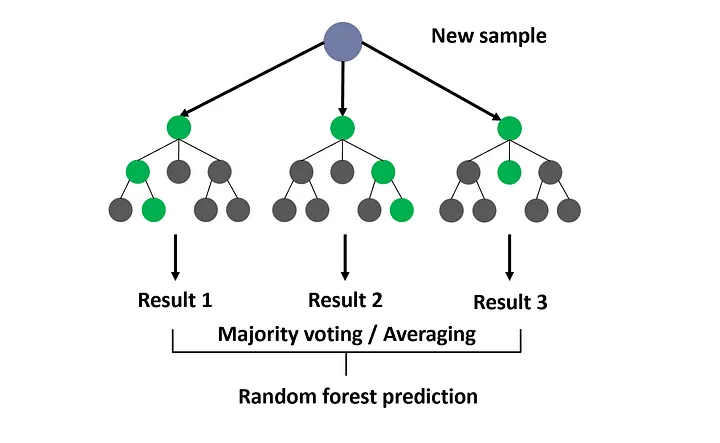

(Yehoshua, 2023)

In [ ]:
#import additional libraries needed

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

Random Forest Model Accuracy: 0.87
Confusion Matrix:
[[2912  695]
 [ 735 6541]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.81      0.80      3607
           1       0.90      0.90      0.90      7276

    accuracy                           0.87     10883
   macro avg       0.85      0.85      0.85     10883
weighted avg       0.87      0.87      0.87     10883

Feature Importances:
                                 Feature  Importance
5                              lead_time    0.365237
13                no_of_special_requests    0.184676
12                    avg_price_per_room    0.104334
7                          arrival_month    0.063286
26            market_segment_type_Online    0.052373
6                           arrival_year    0.048170
25           market_segment_type_Offline    0.027932
8                           arrival_date    0.026618
3                      no_of_week_nights    0.022425
2                  

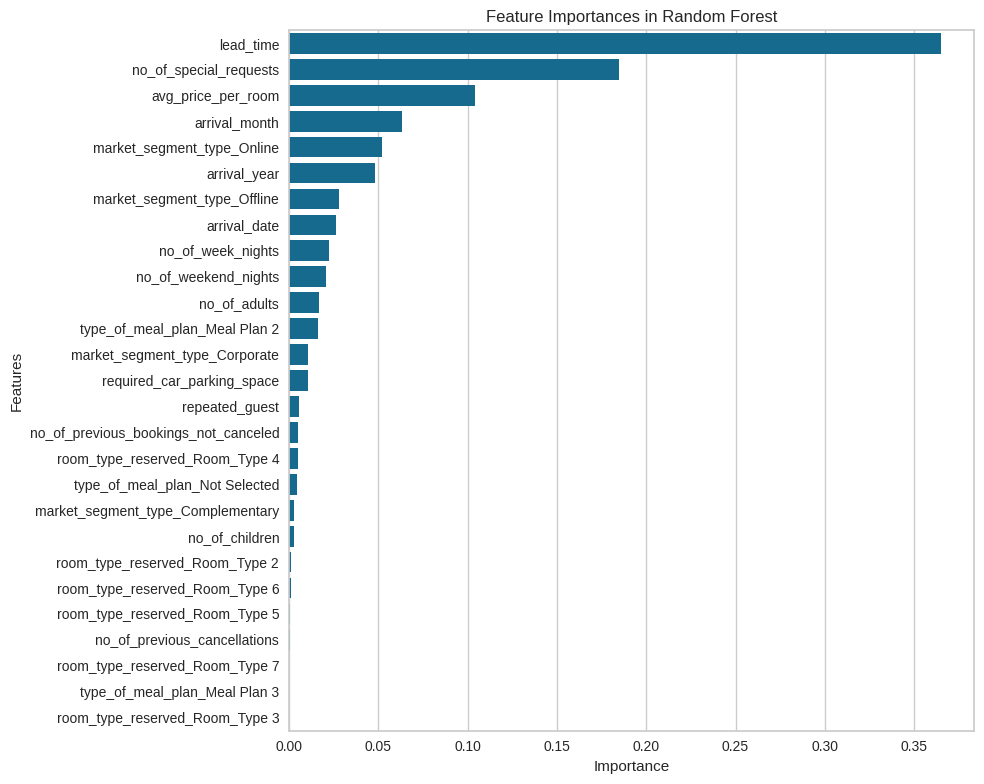

In [ ]:
X = df.drop('booking_status', axis = 1)
y = df['booking_status']

# Convert categorical variables to dummy/indicator variables
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10, class_weight="balanced")

# Train the model on the training set
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Model Accuracy: {accuracy:.2f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Feature Importance
importances = rf_model.feature_importances_
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(feature_importances)

# Plot feature importances (optional)
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_importances['Importance'], y=feature_importances['Feature'])
plt.title("Feature Importances in Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.tight_layout()
plt.show()



###  Traditional Method: Regression Model--Miracle
Linear Regression is a great fit for this dataset because it models the clear linear relationship between \( X \) and \( y \), which was generated with a simple linear trend and some noise. It’s easy to understand, avoids overfitting, and works well with smaller datasets. Since there are no complex patterns or extreme outliers, Linear Regression provides accurate and reliable predictions.

Training Set Evaluation:
Mean Squared Error: 3.39
Mean Absolute Error: 1.47
R^2 Score: 0.94

Test Set Evaluation:
Mean Squared Error: 2.61
Mean Absolute Error: 1.18
R^2 Score: 0.95


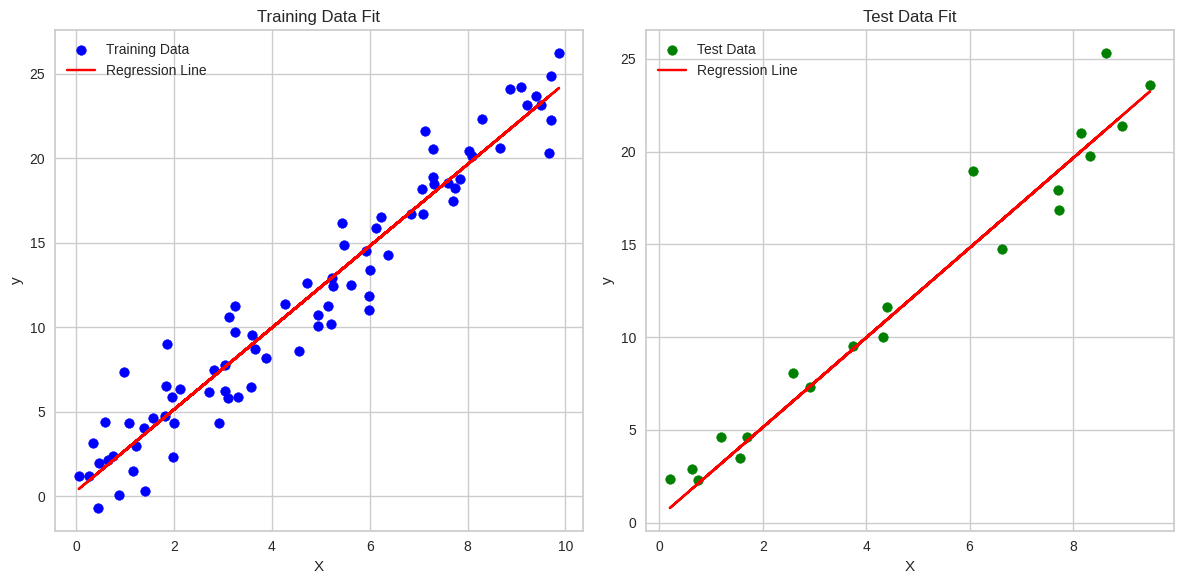

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# Generate synthetic dataset (or replace with your dataset)
# For this example, let's create a simple linear dataset.
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Independent variable
y = 2.5 * X + np.random.randn(100, 1) * 2  # Dependent variable with noise

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evaluate the model
mse_train = mean_squared_error(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

mse_test = mean_squared_error(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

# Print evaluation metrics
print("Training Set Evaluation:")
print(f"Mean Squared Error: {mse_train:.2f}")
print(f"Mean Absolute Error: {mae_train:.2f}")
print(f"R^2 Score: {r2_train:.2f}")

print("\nTest Set Evaluation:")
print(f"Mean Squared Error: {mse_test:.2f}")
print(f"Mean Absolute Error: {mae_test:.2f}")
print(f"R^2 Score: {r2_test:.2f}")

# Visualize the model fit
plt.figure(figsize=(12, 6))

# Plot training data and model
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color="blue", label="Training Data")
plt.plot(X_train, y_pred_train, color="red", label="Regression Line")
plt.title("Training Data Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

# Plot test data and predictions
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color="green", label="Test Data")
plt.plot(X_test, y_pred_test, color="red", label="Regression Line")
plt.title("Test Data Fit")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()

plt.tight_layout()
plt.show()


### Neural Network Model -- Jase

In [ ]:
for x in df.columns[16:]:
    df[x] = df[x].astype(int)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2,0,1,2,0,0.505643,2017,10,2,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,2,3,0,0.011287,2018,11,6,0,...,0,0,0,0,0,0,0,0,0,1
2,1,0,2,1,0,0.002257,2018,2,28,0,...,0,0,0,0,0,0,0,0,0,1
3,2,0,0,2,0,0.476298,2018,5,20,0,...,0,0,0,0,0,0,0,0,0,1
4,2,0,1,1,0,0.108352,2018,4,11,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:

X = df.drop('booking_status', axis = 1)
y = df['booking_status']

In [ ]:
# Create train and test for features and target
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

First start off with a single nueron classifier model.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [ ]:
scaler = StandardScaler()
X_train_processed = scaler.fit_transform(X_train)
X_test_processed = scaler.transform(X_test)

In [ ]:
from sklearn.neural_network import MLPClassifier

mpl_clsf = MLPClassifier(hidden_layer_sizes=[5], max_iter=10_000,
                        random_state=42)

mpl_clsf.fit(X_train_processed, y_train)

MLPClassifier(hidden_layer_sizes=[5], max_iter=10000, random_state=42)

Compare accuracy of model on training and test data

In [ ]:
accuracy = mpl_clsf.score(X_train_processed, y_train)
accuracy

0.8236388697450034

In [ ]:
accuracy_test = mpl_clsf.score(X_test_processed, y_test)
accuracy_test

0.8259131633356306

Next we will look at the confusion matrix of our basic model.

Below we can see that accuracy as mentioned above but also a recall score of 90.5% (4377/(4377+462)).
Precision score is 84.5% (4377/(4377+801))

We should focus to have a higher recall score as we want to identify as many reservations that are not going to be canceled (1) even if that means some false positives. If we get a double booking, customer satisfaction drops and the hotel's reputation and rating is at risk.

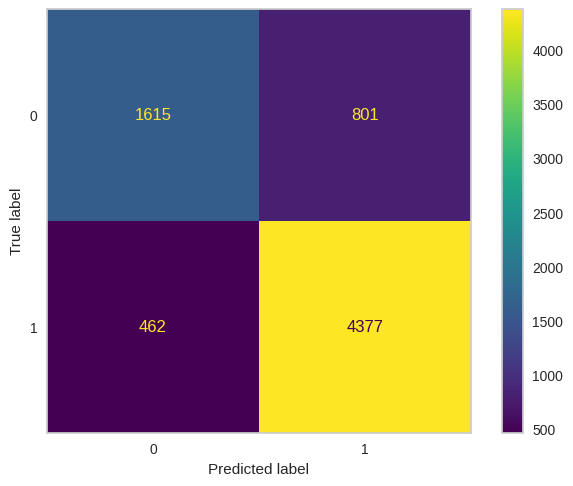

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred_mlp = mpl_clsf.predict(X_test_processed)
cm = confusion_matrix(y_test, y_pred_mlp, labels=mpl_clsf.classes_)
cm
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=mpl_clsf.classes_)
disp.plot()
plt.grid(False)
plt.show()

Now lets see if we can improve accuracy with the use of a Sequential Model

In [ ]:
import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)
model = tf.keras.Sequential()
model.add(tf.keras.layers.InputLayer(input_shape=[27]))
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Below is a table of how our nerural network is structured.

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 300)                 │           8,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 100)                 │          30,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │             101 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 38,601 (150.79 KB)

 Trainable params: 38,601 (150.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), # we are looking to anticipate if a reservation will be canceled or not canceled. A binary result.
              optimizer="sgd", # train the model using stochastic gradient descent
              metrics=["accuracy"])

In [ ]:
history = model.fit(X_train_processed, y_train, epochs=30,
                    validation_data=(X_test_processed, y_test))

Epoch 1/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6878 - loss: 0.5630 - val_accuracy: 0.8058 - val_loss: 0.4232
Epoch 2/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8112 - loss: 0.4135 - val_accuracy: 0.8138 - val_loss: 0.4046
Epoch 3/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8194 - loss: 0.3975 - val_accuracy: 0.8210 - val_loss: 0.3949
Epoch 4/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8272 - loss: 0.3880 - val_accuracy: 0.8256 - val_loss: 0.3878
Epoch 5/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8297 - loss: 0.3806 - val_accuracy: 0.8288 - val_loss: 0.3825
Epoch 6/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8345 - loss: 0.3747 - val_accuracy: 0.8320 - val_loss: 0.3786
Epoch 7/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8372 - loss: 0.3699 - val_accuracy: 0.8320 - val_loss: 0.3753
Epoch 8/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8389 - loss: 0.3658 - val_accuracy: 0.

Nice, the above model gave us an accuracy of 85.8% on the training data and 84.8% on the test set!


Below we see a recall score of 91.6% which is an improvement!

227/227 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


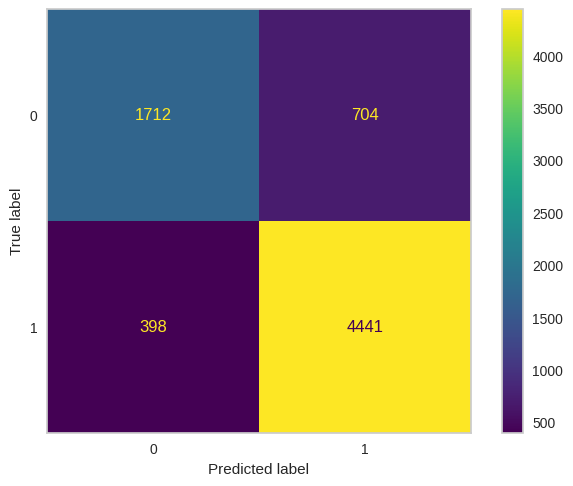

In [ ]:
y_pred1 = model.predict(X_test_processed)
y_pred1_binary = np.where(y_pred1 > 0.5, 1, 0)  # Adjust threshold
cm1 = confusion_matrix(y_test, y_pred1_binary, labels=mpl_clsf.classes_)
cm1
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels= mpl_clsf.classes_)
disp1.plot()
plt.grid(False)
plt.show()

Now we will try to build a more accurate model with RandomSearch.

In [ ]:
# clear kears session

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
%pip install -q -U keras_tuner

In [ ]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256)
    learning_rate = hp.Float("learning_rate", min_value=1e-6, max_value=1e-2,
                             sampling="log") #change sampling to linear instead of log
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model_2 = tf.keras.Sequential()
    model_2.add(tf.keras.layers.InputLayer(input_shape=[27])) # input layer
    for _ in range(n_hidden): # build hidden layer
        model_2.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    model_2.add(tf.keras.layers.Dense(1, activation="sigmoid")) # output layer to sigmoid
    model_2.compile(loss='binary_crossentropy', optimizer=optimizer,
                  metrics=["accuracy"])
    return model_2

In [ ]:
random_search_tuner = kt.RandomSearch(
    build_model, objective="val_accuracy", max_trials=5, overwrite=True,
    directory="my_hotel_cancellation", project_name="my_rnd_search_1", seed=42)
random_search_tuner.search(X_train_processed, y_train, epochs=10,
                           validation_data=(X_test_processed, y_test))


Trial 5 Complete [00h 00m 32s]
val_accuracy: 0.6667126417160034

Best val_accuracy So Far: 0.8588559627532959
Total elapsed time: 00h 03m 14s


In [ ]:
best_trial = random_search_tuner.oracle.get_best_trials(num_trials=1)[0]
best_trial.summary()

Trial 2 summary
Hyperparameters:
n_hidden: 4
n_neurons: 74
learning_rate: 0.008192556279395089
optimizer: adam
Score: 0.8588559627532959


The best model was able to gennerate a testing accuracy of 85%+, our highest yet. Lets run a model with these parameters similar to our first sequential mdoel.

In [ ]:
# clear kears session

tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)
%pip install -q -U keras_tuner

In [ ]:
model3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=[27]),
    tf.keras.layers.Dense(74, activation="relu"),  # n_neurons = 74
    tf.keras.layers.Dense(74, activation="relu"),
    tf.keras.layers.Dense(74, activation="relu"),
    tf.keras.layers.Dense(74, activation="relu"), # n_hidden = 4
    tf.keras.layers.Dense(1, activation="sigmoid")
])

In [ ]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.008192556279395089)
model3.compile(loss="binary_crossentropy", optimizer=optimizer,
               metrics=["accuracy"])

In [ ]:
history3 = model3.fit(X_train_processed, y_train, epochs=30, validation_data=(X_test_processed, y_test))

Epoch 1/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7991 - loss: 0.4356 - val_accuracy: 0.8324 - val_loss: 0.3777
Epoch 2/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8347 - loss: 0.3736 - val_accuracy: 0.8376 - val_loss: 0.3671
Epoch 3/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8444 - loss: 0.3540 - val_accuracy: 0.8420 - val_loss: 0.3410
Epoch 4/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8517 - loss: 0.3390 - val_accuracy: 0.8547 - val_loss: 0.3299
Epoch 5/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8554 - loss: 0.3284 - val_accuracy: 0.8521 - val_loss: 0.3287
Epoch 6/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8570 - loss: 0.3223 - val_accuracy: 0.8525 - val_loss: 0.3308
Epoch 7/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8625 - loss: 0.3190 - val_accuracy: 0.8551 - val_loss: 0.3317
Epoch 8/30
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8634 - loss: 0.3131 - val_accuracy: 

This is the highest test accuracy we achieved with our Keras models, below we will dig deeper into it.



The below matrix shows a recall of 91.5% which is a little bit worse than the previous 91.6%. However this model the precision jumped to 88% as the model was able to classify more true negatives than the previous two.

227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


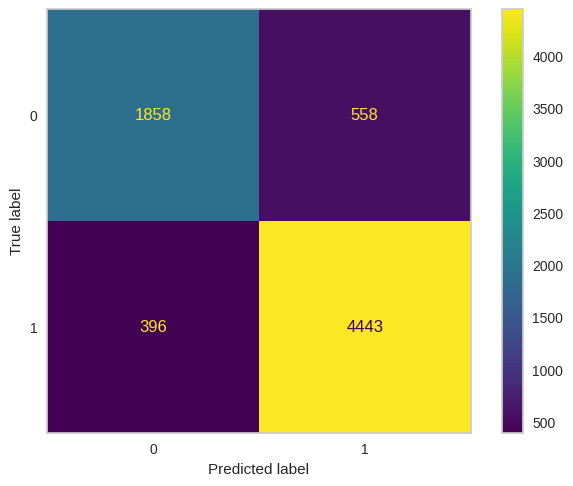

In [ ]:
y_pred2 = model3.predict(X_test_processed)
y_pred2_binary = np.where(y_pred2 > 0.5, 1, 0)  # Adjust threshold
cm2 = confusion_matrix(y_test, y_pred2_binary, labels=mpl_clsf.classes_)
cm2
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels= mpl_clsf.classes_)
disp2.plot()
plt.grid(False)
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

rnn1 = roc_auc_score(y_pred1_binary, y_test)
rnn2 = roc_auc_score(y_pred2_binary, y_test)
print(f'AUC for RNN model one: {rnn1} \n AUC for RNN model two: {rnn2}')

AUC for RNN model one: 0.8372712659877761 
 AUC for RNN model two: 0.8563673245829982


## <font color='navy'>Results and Evaluation </font>


Ensemble Random Forest Model <br>
* Random Forest Model was 87% accurate in predicting whether a booking will be cancelled. There were imbalance challenges and potential overfitting.
* Reduced overfitting by limiting tree depth to 10 (max_depth = 10), used class_weight="balanced" to address class imbalance and ensure fair predictions, and avoided excessive tuning to maintain generalization across unseen data.

Traditonal Linear Regression Model<br>
* These scores indicate that the model explains approximately 94% of the variance in the training set and 95% of the variance in the test set. Thus, the model is highly accurate, capturing most of the relationship between X and y.
* While this model was technically the most accurate, it is not the best fit for this dataset because it is designed to predict continuous outcomes and our dataset is binary (cancelled or not cancelled reservation).
*Linear regression inherently avoids overfitting due to its simplicity.
Used training/test split to evaluate generalization and prevent underfitting.
Relied on the absence of complex patterns in data to minimize overfitting risks.

Neural Network Model <br>
* Deep Learning Model: The last deep learning model created was able to get an accuracy of about 86% which is lower than the other models. However it did contain high recall of 91.5% which can be valuable for the business. Additionally it was only able to obtain an ROC score of 84.82% which is good but not great.
* To prevent overfitting, dropout layers were included by randomly deactivating neurons during training. There were also scaled features and hyperparameters adjusted (e.g., learning rate) to balance model complexity.







**The best model overall was the: Random Forest Model**


## <font color='navy'>Conclusion and Future Work </font>


* Random forest was highly accruate in both cancellations and non-cancellations, similar to the paper cited. The key features included that were strong predictors of cancellations were lead_time, avg_price_per_room, and no_of_special_requests. There was class imbalance and potential overfitting, which can be refined in the future. This is the best model due to being the most accurate, robust, and interpretable.

* The consistent performance of the Traditional Linear regression model on both training and test datasets demonstrates the model's good generalization and avoidance of overfitting.This model provides ease of use, interpretability, and computing efficiency. It efficiently captures the data's trend without the need for more intricate modeling methods. However, it is not the best model because of the binary nature of the dataset (Canceled or Not Cancelled), and Linear Regressions being designed for predicting continuous outcomes.

* The deep learning model offers great flexibility in adjusting hyper parameters for this classification. The model can be scaled up to handle more data as well. This can be used to use different metrics than just accuracy to guage the value of the model. Finally the model can be adjusted fairly easily as data may change over time.

## <font color='navy'>Best Model </font>

* The Random Forest model is the best predictor for determining if a customer will honor their reservation or cancel it, achieving a high accuracy of 87% and effectively handling class imbalance. Of the three models, Random Forest is most robust, interpretable, and efficient, making it the optimal choice for this dataset.

* Because of its high recall of 91.5%, the Deep Learning Model is good alternative model, especially for situations where reducing the chance of missing cancellations is essential. Its capacity to accurately identify cancellations offsets its somewhat lower overall accuracy (86%) compared to other models, particularly if cancellations have a substantial impact on profitability. The model is the best option for companies when finding cancellations is a high concern since it can prioritize crucial instances and capture complicated patterns in the data, despite its computational complexity and lack of interpretability.

## <font color = 'navy'> Future Works </font>

* Future research might concentrate on improving the model's prediction ability by adding more characteristics including seasonality, consumer input, and regional economic statistics. Accuracy might be further increased by addressing class imbalance with sophisticated strategies like SMOTE or customized ensemble approaches. Deeper insights and more confidence in predictions would result from applying explainable AI tools. Furthermore, scalability and practical application would be guaranteed by implementing the model in a real-time hotel management system and verifying it across various datasets. Predictions for busy times of the year or noteworthy occasions may also be enhanced by including time-series analysis.

## <font color='navy'>References and Resources Used </font>


Breiman, L. (2001). "Random Forests." Machine Learning, 45(1), 5-32.
This foundational paper introduces Random Forests, discussing their robustness, speed, and interpretability.

Herrera, A., Arroyo, Á., Jiménez, A., & Herrero, Á. (2024). Forecasting hotel cancellations through machine learning. Expert Systems. https://doi.org/10.1111/exsy.13608

Yehoshua, D. R. (2023, July 17). Random Forests. Medium. https://medium.com/@roiyeho/random-forests-98892261dc49

Resources Used: ChatGPT, Gemini, and MIT-5672-997 Content